#### 1. 计算（日）收益率（对数收盘价之差）时间序列的基本统计量：均值、中位数、标准差、偏度、峰度、最值、自相关系数。

In [1]:
import pandas as pd
info = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/股票类/沪深300成分股信息20220902.xlsx",na_values=[0])
info.head(2)

,代码,简称,收盘价,权重,涨跌,涨跌幅,成交量(万),成交额(万),总股本(亿),自由流通股本(亿),...,申银万国一级行业,申银万国二级行业,申银万国三级行业,中信一级行业,中信二级行业,中信三级行业,恒生一级行业,恒生二级行业,恒生三级行业,沪港通
0,600519.SH,贵州茅台,1875.00,6.2382,-5.89,-0.31,193.91,363516.28,12.56,5.50,...,食品饮料,白酒Ⅱ,白酒Ⅲ,食品饮料,酒类,白酒,NaN,NaN,NaN,沪港通
1,300750.SZ,宁德时代,466.26,3.4526,-1.28,-0.27,1156.09,540829.86,24.40,11.57,...,电力设备,电池,锂电池,电力设备及新能源,新能源动力系统,锂电池,NaN,NaN,NaN,深港通


In [2]:
info.Wind一级行业.unique()

<StringArray>
['日常消费', '工业', '金融', '信息技术', '公用事业', '可选消费', '医疗保健', '材料', '房地产', '能源',
 '电信服务']
Length: 11, dtype: str

In [3]:
info.columns

Index(['代码', '简称', '收盘价', '权重', '涨跌', '涨跌幅', '成交量(万)', '成交额(万)', '总股本(亿)',
       '自由流通股本(亿)', '总市值(亿)', '自由流通市值(亿)', '贡献点', '上市板', '市盈率-TTM', '证监会行业',
       'Wind一级行业', 'Wind二级行业', 'Wind三级行业', 'Wind四级行业', '申银万国一级行业', '申银万国二级行业',
       '申银万国三级行业', '中信一级行业', '中信二级行业', '中信三级行业', '恒生一级行业', '恒生二级行业', '恒生三级行业',
       '沪港通'],
      dtype='str')

In [4]:
# 金融，能源，材料，房地产，日常消费
df = info[info.Wind一级行业.isin(["金融"])]
df[df["总市值(亿)"]==df["总市值(亿)"].max()]

,代码,简称,收盘价,权重,涨跌,涨跌幅,成交量(万),成交额(万),总股本(亿),自由流通股本(亿),...,申银万国一级行业,申银万国二级行业,申银万国三级行业,中信一级行业,中信二级行业,中信三级行业,恒生一级行业,恒生二级行业,恒生三级行业,沪港通
20,601398.SH,工商银行,4.35,0.8069,-0.01,-0.23,12978.47,56511.62,3564.06,338.96,...,银行,国有大型银行Ⅱ,国有大型银行Ⅲ,银行,国有大型银行Ⅱ,国有大型银行Ⅲ,NaN,NaN,NaN,沪港通


In [5]:
# 金融，能源，材料，房地产，日常消费
df = info[info.Wind一级行业.isin(["材料"])]
top5 = df.nlargest(5, "总市值(亿)")
top5.简称

25    万华化学
28    紫金矿业
36    天齐锂业
42    恩捷股份
49    赣锋锂业
Name: 简称, dtype: str

In [6]:
# 股票
import pandas as pd
stock_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/股票类/沪深300成分股收盘价日数据.xlsx",na_values=[0])
stock_data.head(5)

,代码,600519.SH,300750.SZ,601318.SH,600036.SH,000858.SZ,601012.SH,600900.SH,000333.SZ,002594.SZ,...,603087.SH,601236.SH,000800.SZ,002032.SZ,605499.SH,000877.SZ,300979.SZ,601825.SH,601698.SH,001289.SZ
0,股票,贵州茅台,宁德时代,中国平安,招商银行,五粮液,隆基绿能,长江电力,美的集团,比亚迪,...,甘李药业,红塔证券,一汽解放,苏泊尔,东鹏饮料,天山股份,华利集团,沪农商行,中国卫通,龙源电力
1,2010-01-04 00:00:00,103.531132,NaN,20.859549,10.466622,24.706569,NaN,5.434322,NaN,NaN,...,NaN,NaN,21.690557,8.652884,NaN,9.745129,NaN,NaN,NaN,NaN
2,2010-01-05 00:00:00,103.226522,NaN,21.122761,10.478442,24.965812,NaN,5.438442,NaN,NaN,...,NaN,NaN,20.875888,8.640344,NaN,10.513326,NaN,NaN,NaN,NaN
3,2010-01-06 00:00:00,101.593807,NaN,20.673753,10.259772,24.305922,NaN,5.405482,NaN,NaN,...,NaN,NaN,20.307318,8.82845,NaN,10.44748,NaN,NaN,NaN,NaN
4,2010-01-07 00:00:00,99.741774,NaN,20.290547,9.993822,23.567475,NaN,5.335441,NaN,NaN,...,NaN,NaN,19.46719,8.360275,NaN,10.008511,NaN,NaN,NaN,NaN


In [7]:
import numpy as np
np.random.seed(100)

# 5只股票
stocks = ["万华化学","保利发展","工商银行","中国石油","贵州茅台"]

# 数据预处理
stock_data.iloc[0,0] = "日期"
stock_data.columns = stock_data.iloc[0]
stock_data.set_index("日期",inplace=True)
stock_data = stock_data.iloc[1:]
df = stock_data[stocks]
df.isnull().sum()

0
万华化学    0
保利发展    0
工商银行    0
中国石油    0
贵州茅台    0
dtype: int64

统计量计算忽略na

In [8]:
res = pd.DataFrame()
for col in df.columns:
    each = df[col]
    each = each.dropna()
    each = each.apply(pd.to_numeric)
    ret = np.log(each).diff().dropna()
    stats = {
        "均值":ret.mean(),
        "中位数":ret.median(),
        "标准差":ret.std(),
        "偏度":ret.skew(),
        "峰度":ret.kurt(),
        "最大值":ret.max(),
        "最小值":ret.min(),
        "自相关系数":ret.autocorr(),
    }
    each_series = pd.Series(stats)
    res[f"股票_{col}"] = each_series
res

,股票_万华化学,股票_保利发展,股票_工商银行,股票_中国石油,股票_贵州茅台
均值,0.000685,0.000410,0.000153,-0.000187,0.000941
中位数,0.000000,0.000000,0.000000,0.000000,0.000270
标准差,0.024380,0.025743,0.012867,0.015475,0.019648
偏度,-0.026884,0.056562,0.004247,0.006797,0.015606
峰度,2.103996,2.453718,11.318806,9.174149,2.328405
最大值,0.095557,0.095654,0.095310,0.095636,0.095310
最小值,-0.105573,-0.105662,-0.105134,-0.105244,-0.105361
自相关系数,0.009093,0.020617,-0.007732,-0.004141,0.005697


In [9]:
# 期货
future_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期货类/沪深300期货主力日数据.xlsx",na_values=[0])
future_data.head(5)

,代码,名称,日期,开盘价(元),最高价(元),最低价(元),收盘价(元),结算价,成交额(百万),成交量,持仓量
0,IF.CFE,沪深300期货,2010-04-16,3450.0,3488.0,3413.2,3415.6,3431.2,50538.81,48988.0,2702.0
1,IF.CFE,沪深300期货,2010-04-19,3396.0,3398.0,3166.2,3197.4,3201.2,108206.41,109733.0,3954.0
2,IF.CFE,沪深300期货,2010-04-20,3209.2,3240.0,3168.8,3214.6,3216.6,136342.09,141862.0,4496.0
3,IF.CFE,沪深300期货,2010-04-21,3215.0,3281.2,3208.0,3267.2,3266.0,111267.89,114531.0,5062.0
4,IF.CFE,沪深300期货,2010-04-22,3260.2,3274.4,3211.0,3236.2,3240.0,129629.81,133247.0,5383.0


In [10]:
data = future_data["收盘价(元)"].dropna()
ret = np.log(data).diff().dropna()
ret.dtypes

dtype('float64')

In [11]:
res = pd.DataFrame()
stats = {
    "均值":ret.mean(),
    "中位数":ret.median(),
    "标准差":ret.std(),
    "偏度":ret.skew(),
    "峰度":ret.kurt(),
    "最大值":ret.max(),
    "最小值":ret.min(),
    "自相关系数":ret.autocorr(),
}
each_series = pd.Series(stats)
res["期货_沪深300"] = each_series
res

,期货_沪深300
均值,0.000054
中位数,-0.000053
标准差,0.015929
偏度,-0.413533
峰度,7.006755
最大值,0.097371
最小值,-0.106357
自相关系数,-0.003339


In [12]:
# 期权
option_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期权类/上证50ETF认购期权1分钟.xlsx",na_values=[0])
option_data.head(5)

,代码,10003975.SH,10003976.SH,10003977.SH,10003978.SH,10003979.SH,10003980.SH,10003981.SH,10003982.SH,10003983.SH,...,10004243.SH,10004244.SH,10004245.SH,10004273.SH,10004275.SH,10004327.SH,10004331.SH,10004339.SH,10004389.SH,10004401.SH
0,名称,50ETF购9月2850,50ETF购9月2900,50ETF购9月2950,50ETF购9月3000,50ETF购9月3100,50ETF购9月3200,50ETF购9月3300,50ETF购9月3400,50ETF购9月3500,...,50ETF购12月2800,50ETF购12月2850,50ETF购12月2900,50ETF购12月2950,50ETF购12月3000,50ETF购12月3100,50ETF购12月3200,50ETF购12月3300,50ETF购12月3400,50ETF购12月3500
1,2022-08-01 09:30,0.0781,0.0589,0.0417,0.03,0.0145,0.007,0.0041,0.0023,0.0022,...,0.1696,0.14,0.1177,0.1001,0.082,0.0556,0.0366,0.0234,0.0146,0.0107
2,2022-08-01 09:31:00,0.0782,0.0573,0.042,0.03,0.0145,0.0071,0.0039,0.0023,0.0022,...,0.1625,0.1405,0.1155,0.1001,0.081,0.0543,0.0367,0.0237,0.0146,0.0109
3,2022-08-01 09:32:00,0.0798,0.0589,0.0426,0.03,0.0146,0.0071,0.0039,0.0025,0.0024,...,0.164,0.1405,0.119,0.0991,0.0808,0.0561,0.0372,0.0237,0.0153,0.0109
4,2022-08-01 09:33:00,0.0777,0.0575,0.0416,0.0294,0.0142,0.0069,0.0038,0.0024,0.0023,...,0.1625,0.1387,0.1167,0.0975,0.0811,0.0544,0.036,0.0235,0.0149,0.0109


In [13]:
option_data.columns = option_data.iloc[0]
# # 选择一只
data = option_data.iloc[:,1]
data = data[1:]
data = data.dropna()
data = data.apply(pd.to_numeric)
data.dtypes

dtype('float64')

In [14]:
ret = np.log(data).diff().dropna()
stats = {
    "均值":ret.mean(),
    "中位数":ret.median(),
    "标准差":ret.std(),
    "偏度":ret.skew(),
    "峰度":ret.kurt(),
    "最大值":ret.max(),
    "最小值":ret.min(),
    "自相关系数":ret.autocorr(),
}
each_series = pd.Series(stats)
res["期权_上证50ETF认购"] = each_series
res

,期货_沪深300,期权_上证50ETF认购
均值,0.000054,-0.000248
中位数,-0.000053,0.000000
标准差,0.015929,0.012603
偏度,-0.413533,-0.231265
峰度,7.006755,12.004028
最大值,0.097371,0.136393
最小值,-0.106357,-0.147901
自相关系数,-0.003339,-0.076077


In [15]:
# 指数
market_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/市场指数类/沪深300指数日数据.xlsx",na_values=[0])
market_data.head(5)

,代码,名称,日期,开盘价(元),最高价(元),最低价(元),收盘价(元),成交额(百万),成交量(股)
0,000300.SH,沪深300,2002-01-04,1316.46,1316.46,1316.46,1316.46,NaN,NaN
1,000300.SH,沪深300,2002-01-07,1302.08,1302.08,1302.08,1302.08,NaN,NaN
2,000300.SH,沪深300,2002-01-08,1292.71,1292.71,1292.71,1292.71,NaN,NaN
3,000300.SH,沪深300,2002-01-09,1272.65,1272.65,1272.65,1272.65,NaN,NaN
4,000300.SH,沪深300,2002-01-10,1281.26,1281.26,1281.26,1281.26,NaN,NaN


In [16]:
data = market_data["收盘价(元)"].dropna()
ret = np.log(data).diff().dropna()
ret.dtypes

dtype('float64')

In [17]:
stats = {
    "均值":ret.mean(),
    "中位数":ret.median(),
    "标准差":ret.std(),
    "偏度":ret.skew(),
    "峰度":ret.kurt(),
    "最大值":ret.max(),
    "最小值":ret.min(),
    "自相关系数":ret.autocorr(),
}
each_series = pd.Series(stats)
res["市场指数_沪深300"] = each_series
res

,期货_沪深300,期权_上证50ETF认购,市场指数_沪深300
均值,0.000054,-0.000248,0.000223
中位数,-0.000053,0.000000,0.000607
标准差,0.015929,0.012603,0.016271
偏度,-0.413533,-0.231265,-0.407997
峰度,7.006755,12.004028,4.197966
最大值,0.097371,0.136393,0.089748
最小值,-0.106357,-0.147901,-0.096952
自相关系数,-0.003339,-0.076077,0.023000


In [18]:
# ETF
ETF_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/指数ETF类/上证50ETF日数据.xlsx",na_values=[0])
ETF_data.head(5)

,代码,名称,日期,开盘价(元),最高价(元),最低价(元),收盘价(元),成交额(百万),成交量
0,510050.SH,上证50ETF,2005-02-23,0.657,0.658,0.646,0.653,1111.79,1.269742e+09
1,510050.SH,上证50ETF,2005-02-24,0.653,0.653,0.647,0.653,394.14,4.516142e+08
2,510050.SH,上证50ETF,2005-02-25,0.654,0.661,0.652,0.656,446.60,5.064607e+08
3,510050.SH,上证50ETF,2005-02-28,0.655,0.655,0.649,0.650,164.47,1.879652e+08
4,510050.SH,上证50ETF,2005-03-01,0.649,0.651,0.645,0.646,180.57,2.080945e+08


In [19]:
data = ETF_data["收盘价(元)"].dropna()
ret = np.log(data).diff().dropna()
ret.dtypes

dtype('float64')

In [20]:
stats = {
    "均值":ret.mean(),
    "中位数":ret.median(),
    "标准差":ret.std(),
    "偏度":ret.skew(),
    "峰度":ret.kurt(),
    "最大值":ret.max(),
    "最小值":ret.min(),
    "自相关系数":ret.autocorr(),
}
each_series = pd.Series(stats)
res["指数ETF_上证50"] = each_series
res

,期货_沪深300,期权_上证50ETF认购,市场指数_沪深300,指数ETF_上证50
均值,0.000054,-0.000248,0.000223,0.000337
中位数,-0.000053,0.000000,0.000607,0.000000
标准差,0.015929,0.012603,0.016271,0.016916
偏度,-0.413533,-0.231265,-0.407997,-0.155948
峰度,7.006755,12.004028,4.197966,5.070942
最大值,0.097371,0.136393,0.089748,0.095780
最小值,-0.106357,-0.147901,-0.096952,-0.105455
自相关系数,-0.003339,-0.076077,0.023000,-0.010648


#### 2. 绘制收益率时间序列的频率分布直方图，并比较其与常见分布（例如正态分布）的区别。

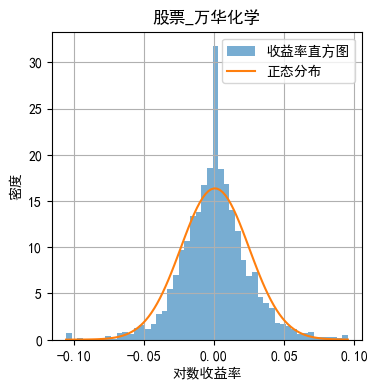

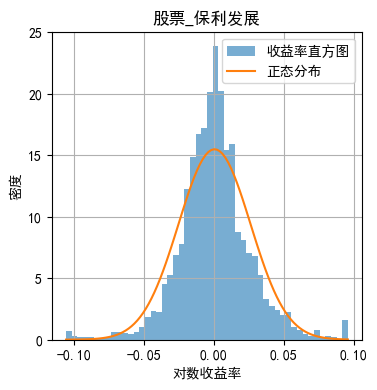

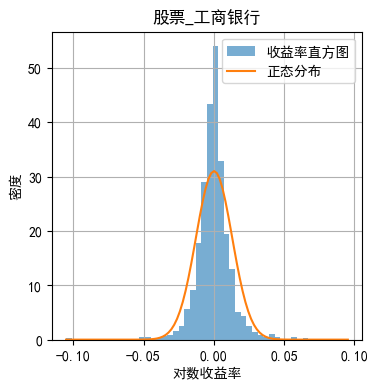

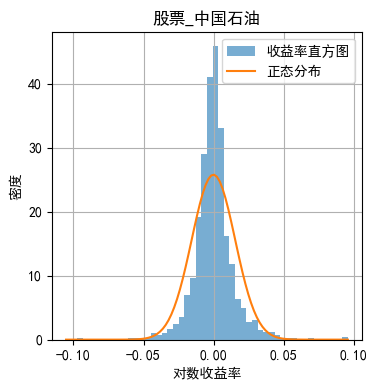

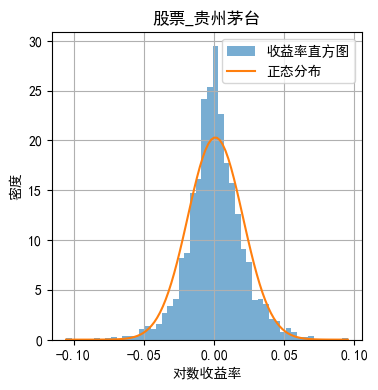

            偏度         峰度         JB统计量             p值
万华化学 -0.026884   2.103996    565.400201  1.678442e-123
保利发展  0.056562   2.453718    770.320567  5.333524e-168
工商银行  0.004247  11.318806  16377.181094   0.000000e+00
中国石油  0.006797   9.174149  10758.091901   0.000000e+00
贵州茅台  0.015606   2.328405    692.236670  4.816338e-151


In [21]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import pandas as pd

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 数据清洗
df = stock_data[stocks]
df.isnull().sum()

res = pd.DataFrame(columns=["偏度","峰度","JB统计量","p值"])

for col in df.columns:

    each = df[col].dropna()
    each = each.apply(pd.to_numeric)

    ret = np.log(each).diff().dropna()

    mu = ret.mean()
    sigma = ret.std()

    # JB检验
    skew = ret.skew()
    kurt = ret.kurt()  
    jb_stat, jb_p = stats.jarque_bera(ret)

    res.loc[col] = [skew, kurt, jb_stat, jb_p]

    x = np.linspace(ret.min(), ret.max(), 100)

    plt.figure(figsize=(4,4))

    plt.hist(ret, bins=50, density=True, alpha=0.6, label="收益率直方图")

    plt.plot(x, stats.norm.pdf(x, mu, sigma), label="正态分布")

    plt.legend()
    plt.grid()

    plt.title(f"股票_{col}")
    plt.xlabel("对数收益率")
    plt.ylabel("密度")

    plt.savefig(
        f"D:/MyProjects/量化交易/Pictures/股票_{col}.png",
        bbox_inches="tight",
        pad_inches=0.1
    )

    plt.show()

print(res)

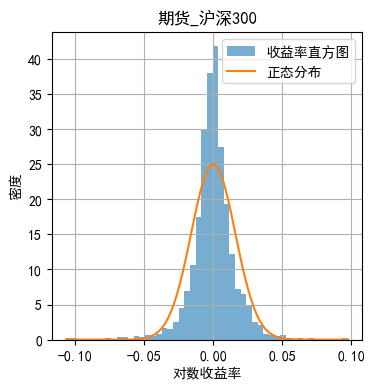

In [22]:
data = future_data["收盘价(元)"].dropna()
ret = np.log(data).diff().dropna()

mu = ret.mean()
sigma = ret.std()

skew = ret.skew()
kurt = ret.kurt()  

jb_stat, jb_p = stats.jarque_bera(ret)

res.loc["期货_沪深300"] = [skew, kurt, jb_stat, jb_p]

x = np.linspace(ret.min(), ret.max(), 100)

plt.figure(figsize=(4,4))

plt.hist(ret, bins=50, density=True, alpha=0.6, label="收益率直方图")
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="正态分布")

plt.legend()
plt.grid()

plt.title("期货_沪深300")
plt.xlabel("对数收益率")
plt.ylabel("密度")

plt.savefig(
    "D:/MyProjects/量化交易/Pictures/期货.png",
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

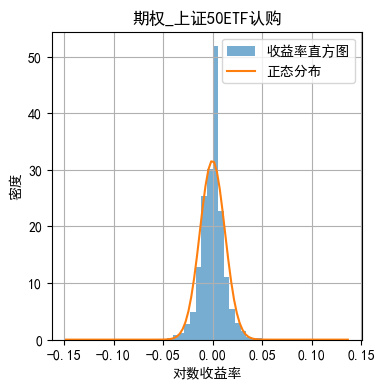

In [23]:
option_data.columns = option_data.iloc[0]

# 选择一只期权
data = option_data.iloc[:,1]
data = data[1:]
data = data.dropna()
data = data.apply(pd.to_numeric)

ret = np.log(data).diff().dropna()

mu = ret.mean()
sigma = ret.std()

# JB检验
skew = ret.skew()
kurt = ret.kurt()  

jb_stat, jb_p = stats.jarque_bera(ret)

res.loc["期权_上证50ETF认购"] = [skew, kurt, jb_stat, jb_p]

x = np.linspace(ret.min(), ret.max(), 100)

plt.figure(figsize=(4,4))

plt.hist(ret, bins=50, density=True, alpha=0.6, label="收益率直方图")
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="正态分布")

plt.legend()
plt.grid()

plt.title("期权_上证50ETF认购")
plt.xlabel("对数收益率")
plt.ylabel("密度")

plt.savefig(
    "D:/MyProjects/量化交易/Pictures/期权.png",
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

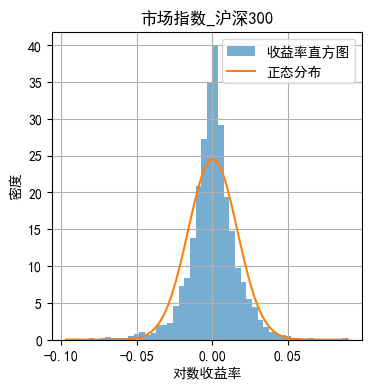

In [24]:
data = market_data["收盘价(元)"].dropna()
ret = np.log(data).diff().dropna()

mu = ret.mean()
sigma = ret.std()

# JB检验
skew = ret.skew()
kurt = ret.kurt()  
jb_stat, jb_p = stats.jarque_bera(ret)

res.loc["市场指数_沪深300"] = [skew, kurt, jb_stat, jb_p]

x = np.linspace(ret.min(), ret.max(), 100)

plt.figure(figsize=(4,4))

plt.hist(ret, bins=50, density=True, alpha=0.6, label="收益率直方图")
plt.plot(x, stats.norm.pdf(x, mu, sigma), label="正态分布")

plt.legend()
plt.grid()

plt.title("市场指数_沪深300")
plt.xlabel("对数收益率")
plt.ylabel("密度")

plt.savefig(
    "D:/MyProjects/量化交易/Pictures/市场指数.png",
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

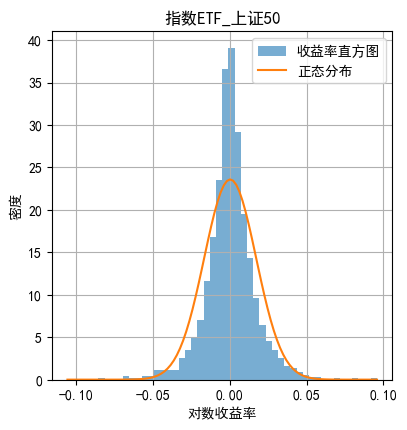

In [25]:
data = ETF_data["收盘价(元)"].dropna()
ret = np.log(data).diff().dropna()

mu = ret.mean()
sigma = ret.std()

# Jb检验
skew = ret.skew()
kurt = ret.kurt()  
jb_stat, jb_p = stats.jarque_bera(ret)

res.loc["指数ETF_上证50"] = [skew, kurt, jb_stat, jb_p]

x = np.linspace(ret.min(), ret.max(), 100)

plt.figure(figsize=(4,4))

plt.hist(ret, bins=50, density=True, alpha=0.6, label="收益率直方图")

plt.plot(x, stats.norm.pdf(x, mu, sigma), label="正态分布")

plt.legend()
plt.grid()
plt.tight_layout()
plt.title(f"指数ETF_上证50")
plt.xlabel("对数收益率")
plt.ylabel("密度")
plt.savefig(
    f"D:/MyProjects/量化交易/Pictures/指数ETF.png",
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()


In [26]:
res

,偏度,峰度,JB统计量,p值
万华化学,-0.026884,2.103996,565.400201,1.678442e-123
保利发展,0.056562,2.453718,770.320567,5.333524e-168
工商银行,0.004247,11.318806,16377.181094,0.000000e+00
中国石油,0.006797,9.174149,10758.091901,0.000000e+00
贵州茅台,0.015606,2.328405,692.236670,4.816338e-151
期货_沪深300,-0.413533,7.006755,6221.135394,0.000000e+00
期权_上证50ETF认购,-0.231265,12.004028,36306.263269,0.000000e+00
市场指数_沪深300,-0.407997,4.197966,3812.072327,0.000000e+00
指数ETF_上证50,-0.155948,5.070942,4575.861866,0.000000e+00


#### 3. 绘制价格时间序列的图像，并关注图像的性质：各时期整体走势、高/低点所处时刻。

In [27]:
# 数据清洗
stock = stock_data.copy()
df = stock[stocks]
df.isnull().sum()
df

,万华化学,保利发展,工商银行,中国石油,贵州茅台
日期,,,,,
2010-01-04 00:00:00,10.559473,4.813541,2.718411,9.633489,103.531132
2010-01-05 00:00:00,10.35374,4.664079,2.743817,9.817253,103.226522
2010-01-06 00:00:00,10.716009,4.659683,2.71333,9.682964,101.593807
2010-01-07 00:00:00,10.35374,4.661881,2.647275,9.619353,99.741774
2010-01-08 00:00:00,10.089865,4.723424,2.657438,9.506268,98.693912
...,...,...,...,...,...
2022-08-29 00:00:00,87.8,16.61,4.33,5.48,1878.82
2022-08-30 00:00:00,88.45,16.95,4.36,5.47,1870
2022-08-31 00:00:00,88.57,17.3,4.38,5.34,1924


max:2021-02-18 00:00:00
min:2010-07-05 00:00:00
max:2022-04-15 00:00:00
min:2010-05-17 00:00:00
max:2018-02-05 00:00:00
min:2014-03-11 00:00:00
max:2015-04-27 00:00:00
min:2020-10-29 00:00:00
max:2021-02-10 00:00:00
min:2010-06-29 00:00:00


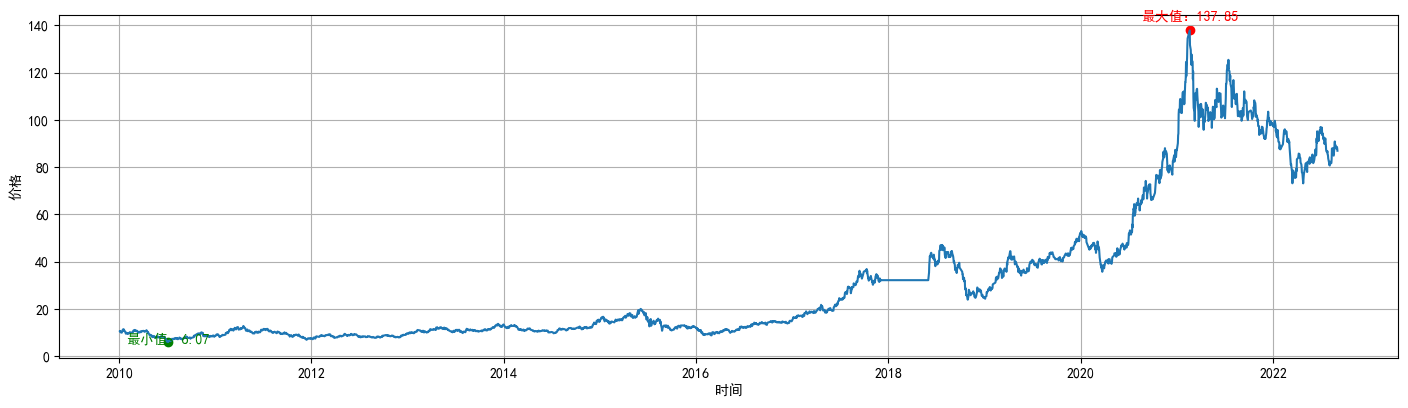

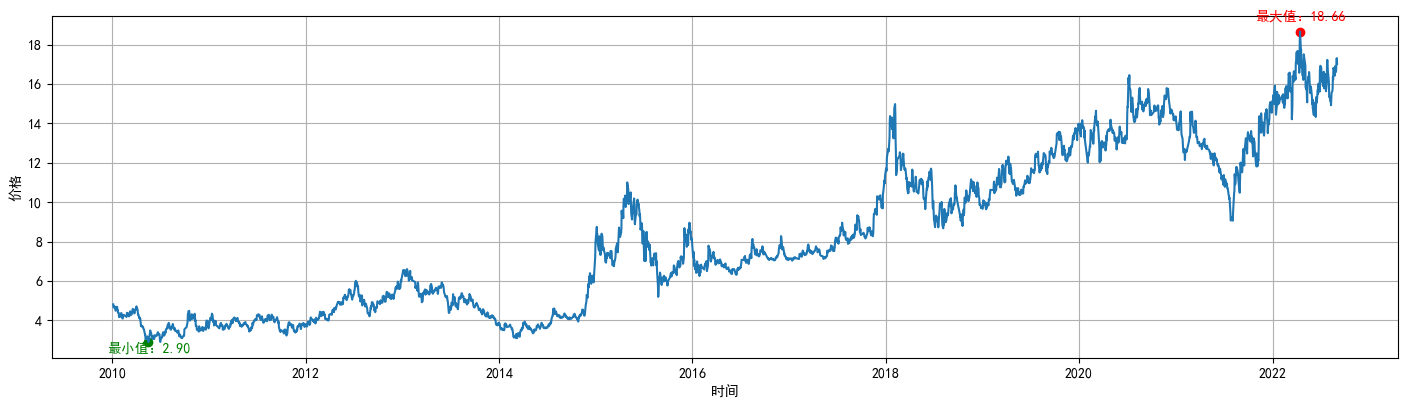

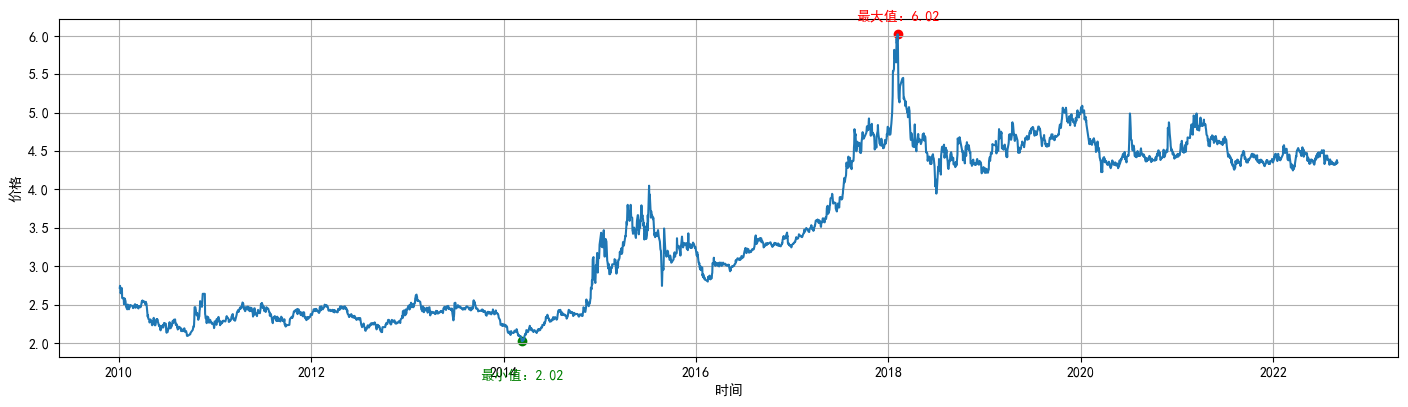

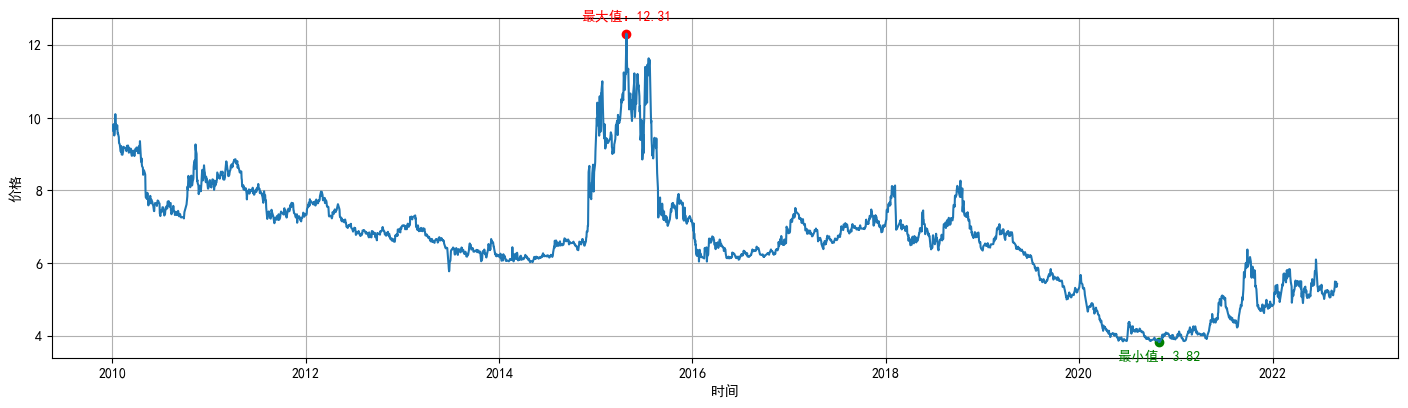

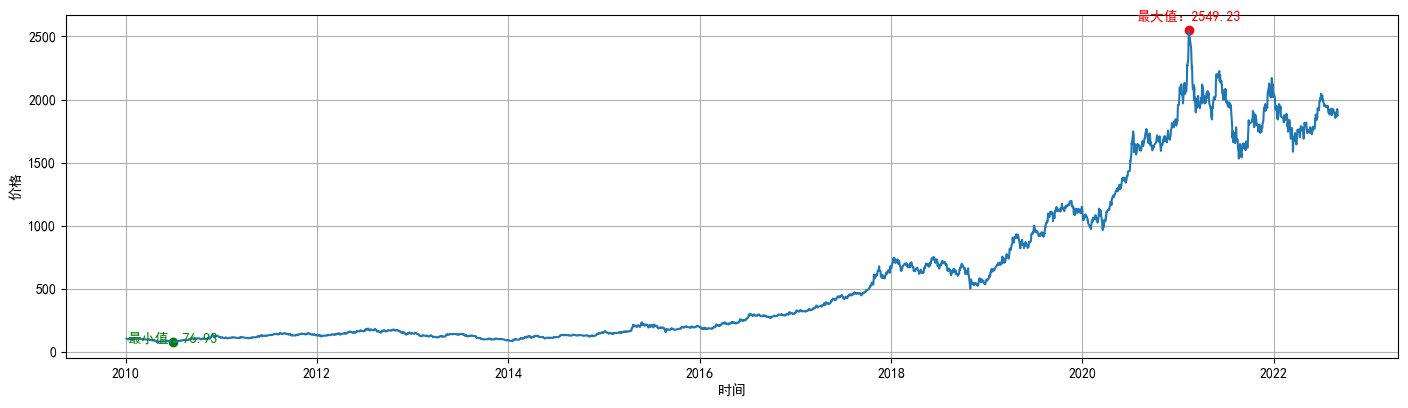

In [28]:
for col in df.columns:
    each = df[col]
    each = each.dropna()
    each = each.apply(pd.to_numeric)
    
    max_price = each.max()
    min_price = each.min()

    max_date = each.idxmax()
    min_date = each.idxmin()
    
    print(f"max:{max_date}")
    print(f"min:{min_date}")

    plt.figure(figsize=(14,4))
    plt.plot(each)

    plt.scatter(max_date,max_price,color="red")
    plt.scatter(min_date,min_price,color="green")
    plt.text(max_date, max_price*1.03,
            f"最大值：{max_price:.2f}",
            color="red",
            ha="center")
    plt.text(min_date, min_price-0.5,
            f"最小值：{min_price:.2f}",
            color="green",
            ha="center")
    
    plt.grid()
    plt.tight_layout()
    plt.xlabel("时间")
    plt.ylabel("价格")
    plt.savefig(f"D:/MyProjects/量化交易/Pictures/股票_{col}_价格.png")
    

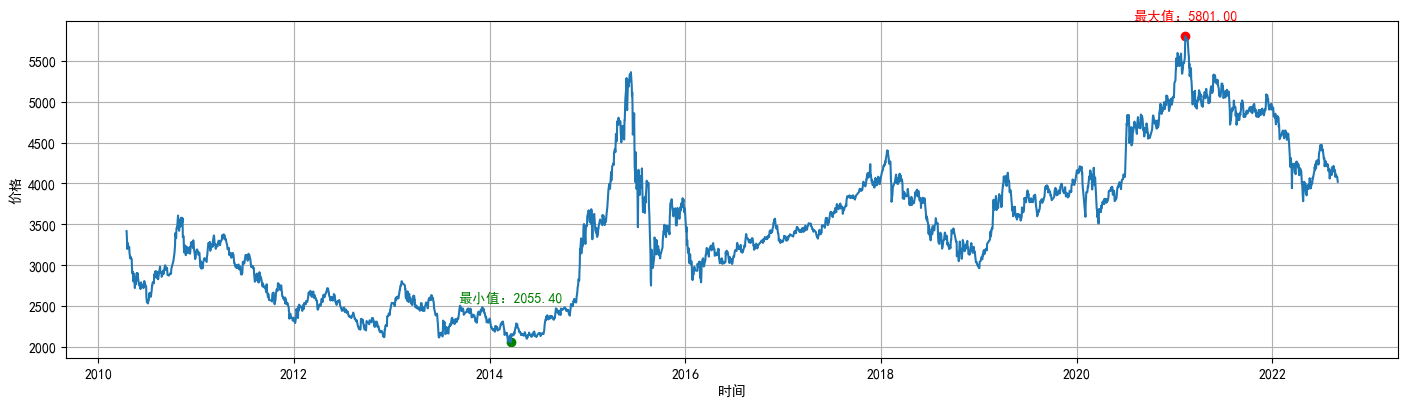

In [29]:
future = future_data.copy()
future.set_index("日期",inplace=True)
data = future["收盘价(元)"].dropna()

max_price = data.max()
min_price = data.min()

max_date = data.idxmax()
min_date = data.idxmin()

plt.figure(figsize=(14,4))
plt.plot(data)
plt.scatter(max_date,max_price,color="red")
plt.scatter(min_date,min_price,color="green")
plt.text(max_date, max_price+200,
         f"最大值：{max_price:.2f}",
         color="red",
         ha="center")
plt.text(min_date, min_price+500,
         f"最小值：{min_price:.2f}",
         color="green",
         ha="center")

plt.grid()
plt.tight_layout()
plt.xlabel("时间")
plt.ylabel("价格")
plt.savefig(f"D:/MyProjects/量化交易/Pictures/期货_价格.png")

In [30]:
print(min_date,max_date)

2014-03-20 00:00:00 2021-02-10 00:00:00


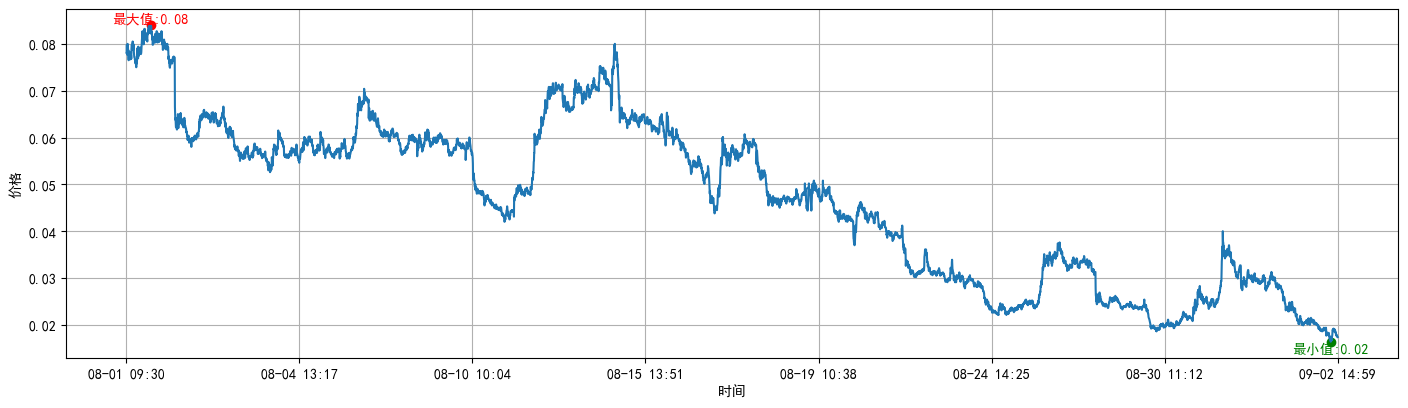

In [31]:
option = option_data.copy()
option.columns = option.iloc[0]
option.set_index("名称",inplace=True)
option = option.iloc[1:]
option.index = pd.to_datetime(option.index)
# 选择一只
data = option.iloc[:,0]
data = data.dropna()
data = data.apply(pd.to_numeric)

s = data.sort_index()
x = np.arange(len(s))

step = len(s)//7
ticks = x[::step]
labels = s.index[::step].strftime("%m-%d %H:%M")

fig = plt.figure(figsize=(14,4))
plt.plot(x,data.values)

plt.xticks(ticks, labels, rotation=0)

max_price = s.max()
min_price = s.min()

max_pos = s.values.argmax()
min_pos = s.values.argmin()

plt.scatter(max_pos, max_price, color="red")
plt.scatter(min_pos, min_price, color="green")

plt.text(max_pos, max_price,
         f"最大值:{max_price:.2f}",
         color="red",
         ha="center",
         va="bottom")

plt.text(min_pos, min_price,
         f"最小值:{min_price:.2f}",
         color="green",
         ha="center",
         va="top")

plt.grid()
plt.tight_layout()
plt.xlabel("时间")
plt.ylabel("价格")
plt.savefig(f"D:/MyProjects/量化交易/Pictures/期权_价格.png")

In [32]:
print(min_date,max_date)

2014-03-20 00:00:00 2021-02-10 00:00:00


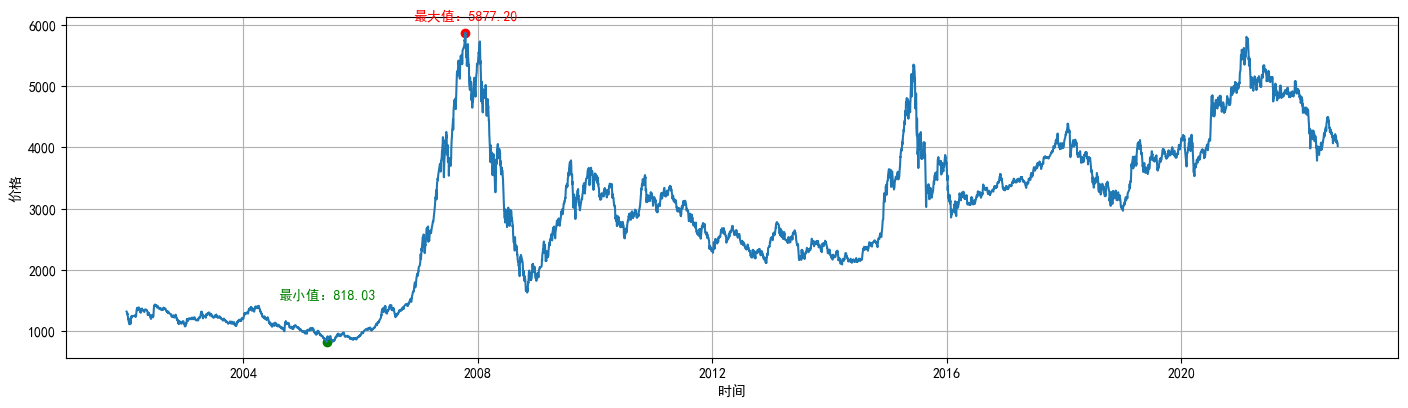

In [33]:
market = market_data.copy()
market.set_index("日期",inplace=True)
data = market["收盘价(元)"].dropna()

max_price = data.max()
min_price = data.min()

max_date = data.idxmax()
min_date = data.idxmin()

plt.figure(figsize=(14,4))
plt.plot(data)
plt.scatter(max_date,max_price,color="red")
plt.scatter(min_date,min_price,color="green")
plt.text(max_date, max_price+200,
         f"最大值：{max_price:.2f}",
         color="red",
         ha="center")
plt.text(min_date, min_price+700,
         f"最小值：{min_price:.2f}",
         color="green",
         ha="center")

plt.grid()
plt.tight_layout()
plt.xlabel("时间")
plt.ylabel("价格")
plt.savefig(f"D:/MyProjects/量化交易/Pictures/市场指数_价格.png")

In [34]:
print(min_date,max_date)

2005-06-03 00:00:00 2007-10-16 00:00:00


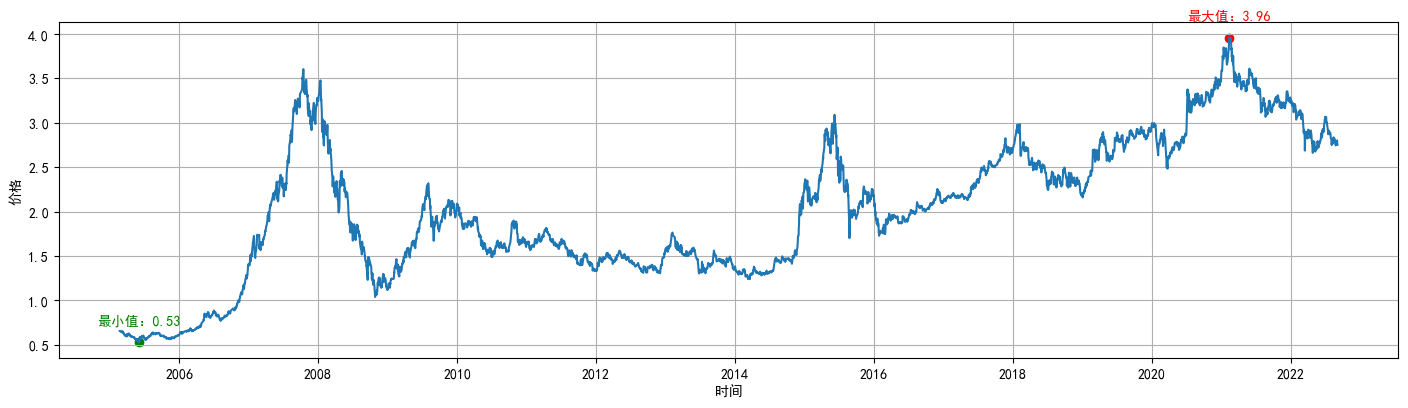

In [35]:
ETF = ETF_data.copy()
ETF.set_index("日期",inplace=True)
data = ETF["收盘价(元)"].dropna()

max_price = data.max()
min_price = data.min()

max_date = data.idxmax()
min_date = data.idxmin()

plt.figure(figsize=(14,4))
plt.plot(data)
plt.scatter(max_date,max_price,color="red")
plt.scatter(min_date,min_price,color="green")
plt.text(max_date, max_price+0.2,
         f"最大值：{max_price:.2f}",
         color="red",
         ha="center")
plt.text(min_date, min_price+0.2,
         f"最小值：{min_price:.2f}",
         color="green",
         ha="center")

plt.grid()
plt.tight_layout()
plt.xlabel("时间")
plt.ylabel("价格")
plt.savefig(f"D:/MyProjects/量化交易/Pictures/指数ETF_价格.png")

In [36]:
print(min_date,max_date)

2005-06-03 00:00:00 2021-02-10 00:00:00


#### 4. 不同股票的同期收益率的相关性，不同品种的期货的收益率的相关性。

In [37]:
stock = stock_data.copy()
df = stock[stocks]
df = df.dropna()
ret = pd.DataFrame()
for col in df.columns:
    ret[col] = np.log(pd.to_numeric(df[col])).diff().dropna()
corr_matrix = ret.corr().round(2)
corr_matrix

,万华化学,保利发展,工商银行,中国石油,贵州茅台
万华化学,1.00,0.41,0.29,0.34,0.39
保利发展,0.41,1.00,0.47,0.42,0.30
工商银行,0.29,0.47,1.00,0.51,0.26
中国石油,0.34,0.42,0.51,1.00,0.22
贵州茅台,0.39,0.30,0.26,0.22,1.00


In [38]:
top5 = ['万华化学','紫金矿业','天齐锂业','恩捷股份','赣锋锂业']
stock = stock_data.copy()
df = stock[top5]
df = df.dropna()
ret = pd.DataFrame()
for col in df.columns:
    ret[col] = np.log(pd.to_numeric(df[col])).diff().dropna()
corr_matrix = ret.corr().round(2)
corr_matrix

,万华化学,紫金矿业,天齐锂业,恩捷股份,赣锋锂业
万华化学,1.00,0.34,0.24,0.20,0.30
紫金矿业,0.34,1.00,0.28,0.12,0.32
天齐锂业,0.24,0.28,1.00,0.34,0.73
恩捷股份,0.20,0.12,0.34,1.00,0.44
赣锋锂业,0.30,0.32,0.73,0.44,1.00


In [39]:
top5 = ['保利发展','万科A','招商蛇口','金地集团','新城控股']
stock = stock_data.copy()
df = stock[top5]
df = df.dropna()
ret = pd.DataFrame()
for col in df.columns:
    ret[col] = np.log(pd.to_numeric(df[col])).diff().dropna()
corr_matrix = ret.corr().round(2)
corr_matrix

,保利发展,万科A,招商蛇口,金地集团,新城控股
保利发展,1.00,0.70,0.77,0.77,0.66
万科A,0.70,1.00,0.59,0.68,0.58
招商蛇口,0.77,0.59,1.00,0.67,0.61
金地集团,0.77,0.68,0.67,1.00,0.58
新城控股,0.66,0.58,0.61,0.58,1.00


In [40]:
top5 = ['工商银行','建设银行','农业银行','中国银行','招商银行']
stock = stock_data.copy()
df = stock[top5]
df = df.dropna()
ret = pd.DataFrame()
for col in df.columns:
    ret[col] = np.log(pd.to_numeric(df[col])).diff().dropna()
corr_matrix = ret.corr().round(2)
corr_matrix

,工商银行,建设银行,农业银行,中国银行,招商银行
工商银行,1.00,0.84,0.85,0.81,0.66
建设银行,0.84,1.00,0.84,0.81,0.70
农业银行,0.85,0.84,1.00,0.85,0.66
中国银行,0.81,0.81,0.85,1.00,0.63
招商银行,0.66,0.70,0.66,0.63,1.00


In [41]:
top5 = ['中国石油','中国神华','中国石化','兖矿能源','陕西煤业']
stock = stock_data.copy()
df = stock[top5]
df = df.dropna()
ret = pd.DataFrame()
for col in df.columns:
    ret[col] = np.log(pd.to_numeric(df[col])).diff().dropna()
corr_matrix = ret.corr().round(2)
corr_matrix

,中国石油,中国神华,中国石化,兖矿能源,陕西煤业
中国石油,1.00,0.57,0.81,0.47,0.44
中国神华,0.57,1.00,0.60,0.69,0.69
中国石化,0.81,0.60,1.00,0.47,0.47
兖矿能源,0.47,0.69,0.47,1.00,0.75
陕西煤业,0.44,0.69,0.47,0.75,1.00


In [42]:
top5 = ['贵州茅台','五粮液','海天味业','山西汾酒','泸州老窖']
stock = stock_data.copy()
df = stock[top5]
df = df.dropna()
ret = pd.DataFrame()
for col in df.columns:
    ret[col] = np.log(pd.to_numeric(df[col])).diff().dropna()
corr_matrix = ret.corr().round(2)
corr_matrix

,贵州茅台,五粮液,海天味业,山西汾酒,泸州老窖
贵州茅台,1.00,0.77,0.48,0.62,0.71
五粮液,0.77,1.00,0.51,0.72,0.81
海天味业,0.48,0.51,1.00,0.49,0.49
山西汾酒,0.62,0.72,0.49,1.00,0.73
泸州老窖,0.71,0.81,0.49,0.73,1.00


In [43]:
future1_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期货类/动力煤期货主力1分钟.xlsx",na_values=[0])
future2_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期货类/豆粕期货主力1分钟.xlsx",na_values=[0])
future3_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期货类/沪镍期货主力1分钟.xlsx",na_values=[0])
future4_data = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期货类/螺纹钢期货主力1分钟.xlsx",na_values=[0])

In [44]:
data = pd.DataFrame()
for i in range(1,5):
    future = eval(f"future{i}_data")
    future = future[["日期","收盘价(元)"]]
    future.set_index("日期",inplace=True)
    future = future.dropna()
    data[f"期货_{i}"] = np.log(pd.to_numeric(future["收盘价(元)"])).diff().dropna()
data = data.dropna()
data.columns = ["动力煤","豆粕","沪镍","螺纹钢"]
corr_matrix = data.corr().round(2)
corr_matrix

,动力煤,豆粕,沪镍,螺纹钢
动力煤,1.00,-0.01,0.05,-0.01
豆粕,-0.01,1.00,0.37,0.19
沪镍,0.05,0.37,1.00,0.42
螺纹钢,-0.01,0.19,0.42,1.00


#### 5. 同一个指数，其本身、ETF和期货三者的价格或收益率序列的关系。

In [45]:
index_self = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/市场指数类/上证50指数日数据.xlsx",na_values=[0])
index_ETF = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/指数ETF类/上证50ETF日数据.xlsx",na_values=[0])
index_future = pd.read_excel("D:/MyProjects/量化交易/Data/量化交易2026春-第1次作业数据/期货类/上证50期货主力日数据.xlsx",na_values=[0])

In [46]:
data = pd.DataFrame()
for df in [index_self,index_ETF,index_future]:
    name = df["名称"].iloc[0]
    df = df[["日期","收盘价(元)"]]
    df.set_index("日期",inplace=True)
    df = df.dropna()
    data[f"{name}"] = np.log(pd.to_numeric(df["收盘价(元)"])).diff().dropna()
data = data.dropna()
mat = data.corr().round(2)
mat

,上证50,上证50ETF,上证50期货
上证50,1.00,0.99,0.95
上证50ETF,0.99,1.00,0.96
上证50期货,0.95,0.96,1.00
